Part A: Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

Part B: Dataset Loading

In [ ]:
df = sns.load_dataset('titanic')
print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Useful columns: pclass, sex, age, sibsp, parch, fare, embarked. These carry meaningful signal about survival chances.

Columns to exclude:

deck: over 75% missing, too sparse to be reliable.
embark_town: duplicate of embarked, just a string version.
who, adult_male, alive: these are derived from or directly equivalent to other columns, so they leak or duplicate information.
class: categorical duplicate of pclass.
alone: derived from sibsp and parch, redundant.
survived is the target, not a feature.

Part C: Data Cleaning

Part C.1: Survival Rate by Categorical Features

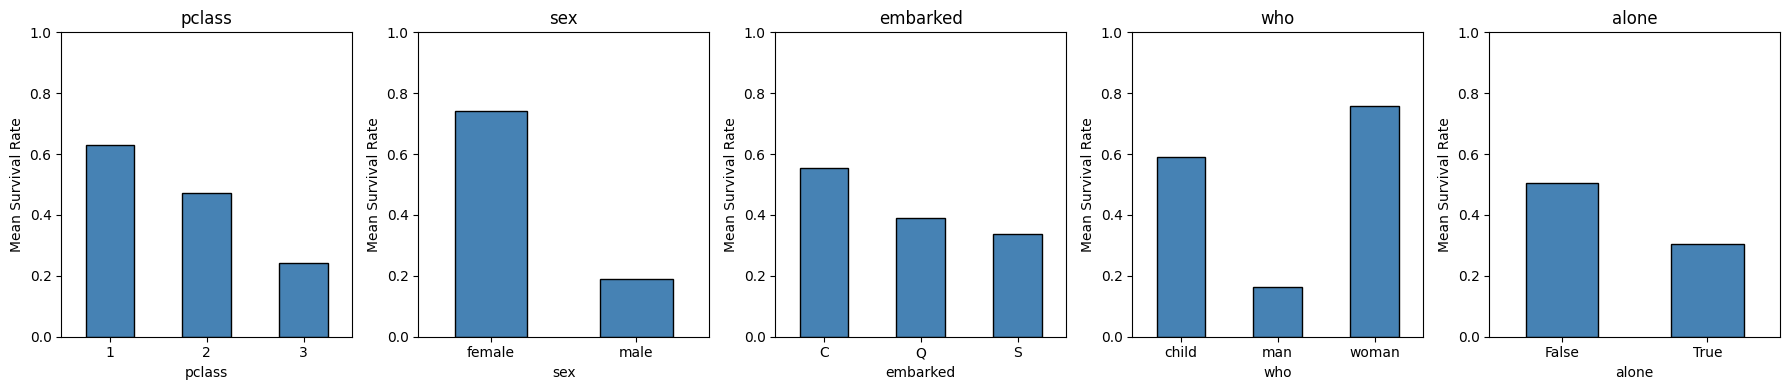

In [ ]:
categorical_cols = ['pclass', 'sex', 'embarked', 'who', 'alone']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(18, 4))

for ax, col in zip(axes, categorical_cols):
    survival_rate = df.groupby(col)['survived'].mean()
    survival_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_ylabel('Mean Survival Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Part C.2: Feature Selection

In [ ]:
cols_to_keep = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df_clean = df[cols_to_keep].copy()

df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['fare'] = df_clean['fare'].fillna(df_clean['fare'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)

bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

print('X shape:', X.shape)
print('y shape:', y.shape)
df_clean.head()

X shape: (891, 8)
y shape: (891,)


,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,1,0,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,3,26.0,0,0,7.9250,1,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,1


Part D: Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train class balance:')
print(y_train.value_counts(normalize=True))
print('y_test class balance:')
print(y_test.value_counts(normalize=True))

X_train: (712, 8)
X_test: (179, 8)
y_train class balance:
survived
0    0.623596
1    0.376404
Name: proportion, dtype: float64
y_test class balance:
survived
0    0.586592
1    0.413408
Name: proportion, dtype: float64


Part F: Decision Tree from Scratch

In [ ]:
class Node:
    def __init__(self, left=None, right=None, feature=None, threshold=None, classifier=None):
        self.left = left
        self.right = right
        self.feature = feature
        self.threshold = threshold
        self.classifier = classifier

    def is_leaf(self):
        return self.classifier is not None


class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples = min_samples_split
        self.root = None

    def fit(self, Xy):
        self.root = self._make_tree(Xy, depth=0)

    def predict(self, X):
        X_arr = np.array(X)
        return np.array([self._traverse(row, self.root) for row in X_arr])

    def _traverse(self, row, node):
        if node.is_leaf():
            return node.classifier
        if row[node.feature] <= node.threshold:
            return self._traverse(row, node.left)
        return self._traverse(row, node.right)

    def _make_tree(self, Xy, depth):
        labels = Xy[:, -1]
        n = len(labels)

        if depth >= self.max_depth or n < self.min_samples or len(np.unique(labels)) == 1:
            return Node(classifier=int(np.bincount(labels.astype(int)).argmax()))

        best = self._best_split(Xy)
        if best is None:
            return Node(classifier=int(np.bincount(labels.astype(int)).argmax()))

        feat, thresh, ig = best
        if ig <= 0:
            return Node(classifier=int(np.bincount(labels.astype(int)).argmax()))

        left_mask = Xy[:, feat] <= thresh
        right_mask = ~left_mask

        left_node = self._make_tree(Xy[left_mask], depth + 1)
        right_node = self._make_tree(Xy[right_mask], depth + 1)

        return Node(left=left_node, right=right_node, feature=feat, threshold=thresh)

    def _best_split(self, Xy):
        n_features = Xy.shape[1] - 1
        parent_gini = self._gini_of_data(Xy)
        best_ig = -1
        best_feat = None
        best_thresh = None

        for feat in range(n_features):
            values = np.unique(Xy[:, feat])
            thresholds = (values[:-1] + values[1:]) / 2

            for thresh in thresholds:
                left = Xy[Xy[:, feat] <= thresh]
                right = Xy[Xy[:, feat] > thresh]

                if len(left) == 0 or len(right) == 0:
                    continue

                ig = self._information_gain(parent_gini, left, right)
                if ig > best_ig:
                    best_ig = ig
                    best_feat = feat
                    best_thresh = thresh

        if best_feat is None:
            return None
        return best_feat, best_thresh, best_ig

    def _gini_of_data(self, Xy):
        labels = Xy[:, -1].astype(int)
        n = len(labels)
        if n == 0:
            return 0
        counts = np.bincount(labels)
        probs = counts / n
        return 1 - np.sum(probs ** 2)

    def _information_gain(self, parent_H, left, right):
        n = len(left) + len(right)
        weighted_child = (len(left) / n) * self._gini_of_data(left) + (len(right) / n) * self._gini_of_data(right)
        return parent_H - weighted_child

Part G: Max Depth

Accuracy: 0.7989
F1 Score: 0.7273
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



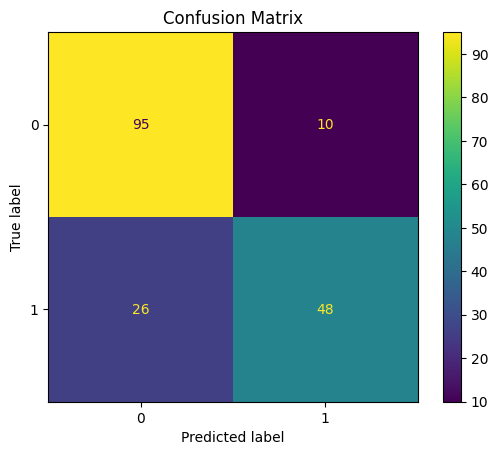

In [ ]:
Xy_train = np.column_stack([X_train.values, y_train.values])

tree = DecisionTree(max_depth=5, min_samples_split=5)
tree.fit(Xy_train)

y_pred = tree.predict(X_test.values)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy:', round(acc, 4))
print('F1 Score:', round(f1, 4))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

If accuracy is around 60%, the most likely cause is that max_depth is too low, so the tree underfits and cannot capture the actual decision boundaries in the data. With shallow splits, the model misses important interactions like sex combined with pclass, which together are highly predictive.

In [ ]:
print('Class distribution in training set:')
print(y_train.value_counts())
print('Survival rate in training set:', y_train.mean().round(3))

print('\nFeature-level survival correlation:')
train_df = X_train.copy()
train_df['survived'] = y_train.values
print(train_df.corr()['survived'].sort_values(ascending=False))

Class distribution in training set:
survived
0    444
1    268
Name: count, dtype: int64
Survival rate in training set: 0.376

Feature-level survival correlation:
survived      1.000000
fare          0.246641
parch         0.078311
embarked_Q   -0.006097
sibsp        -0.047602
age          -0.048588
embarked_S   -0.134623
pclass       -0.321750
sex_male     -0.541750
Name: survived, dtype: float64


Part H: Different Max Depth Values

Best max_depth: 7 with accuracy: 0.8101


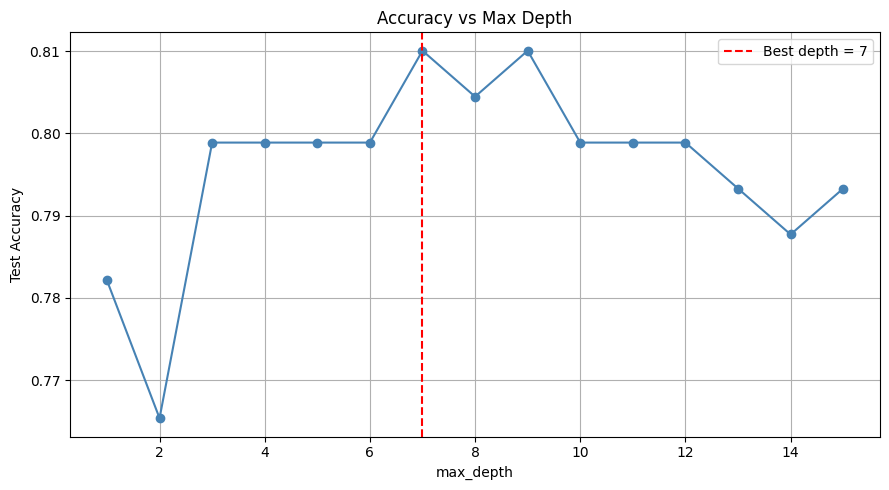

In [ ]:
depths = list(range(1, 16))
accuracies = []

for d in depths:
    t = DecisionTree(max_depth=d, min_samples_split=5)
    t.fit(Xy_train)
    preds = t.predict(X_test.values)
    accuracies.append(accuracy_score(y_test, preds))

best_depth = depths[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f'Best max_depth: {best_depth} with accuracy: {round(best_acc, 4)}')

plt.figure(figsize=(9, 5))
plt.plot(depths, accuracies, marker='o', color='steelblue')
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs Max Depth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

At very low depths the tree underfits, so accuracy is low. As depth increases, the model learns more of the actual structure and accuracy goes up. But beyond a certain point, accuracy plateaus or slightly drops because the tree starts memorizing noise in the training data. The best depth sits in the middle where generalization is highest. This pattern confirms that depth is a direct control on the bias-variance tradeoff. Too shallow means high bias. Too deep means high variance. The sweet spot gives the best test performance.